# SVM Implementation with Linear & RBF Kernels using NumPy (from scratch) and Scikit-learn


### Learning Objectives
- Build intuition for SVM margins and support vectors.
- Implement a simple linear soft-margin SVM with NumPy from scratch.
- Train linear and RBF SVMs using scikit-learn.
- Tune hyperparameters (`C`, `gamma`) and compare model behavior.
- Evaluate SVMs on a real-world binary classification dataset.

### Prerequisites
- NumPy arrays and vectorized operations
- Matplotlib / Seaborn plotting
- scikit-learn basics
- train-test split and feature scaling

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
np.random.seed(42)
print("Imports loaded.")

Imports loaded.


## 2) Brief Theory Recap

- **Hard margin SVM**: assumes perfect linear separability.
- **Soft margin SVM**: allows some margin violations using hinge loss.
- **Support vectors**: critical points that define the decision boundary.
- **Primal objective** (soft margin):

$$\min_{w,b}\;\frac{1}{2}\|w\|^2 + C\sum_i\max(0,1-y_i(w^Tx_i+b))$$

- **Kernel trick** maps data implicitly:
  - Linear: $K(x_i,x_j)=x_i^Tx_j$
  - RBF: $K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$
- Hyperparameters:
  - `C`: regularization vs misclassification trade-off
  - `gamma`: locality/complexity of RBF boundary

## 3) Guided Example – Simple Synthetic Dataset (`make_moons`)

Dataset: `make_moons(n_samples=300, noise=0.15, random_state=42)`

In [4]:
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
print("X shape:", X.shape)
print("Class counts:", np.bincount(y))


X shape: (300, 2)
Class counts: [150 150]


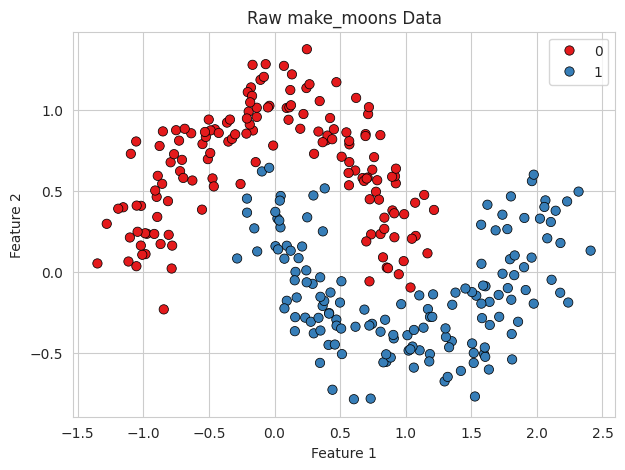

In [5]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=45, edgecolor="k")
plt.title("Raw make_moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [6]:
def plot_decision_boundary(model, X, y, ax=None, title="Decision Boundary", plot_support=True):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=35, edgecolor="k", ax=ax, legend=False)
    if plot_support and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="black", linewidths=1.5)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

### 3A) NumPy from-scratch part (Linear SVM only) — FIRST

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

Train shape: (225, 2) Test shape: (75, 2)


In [8]:
class LinearSVMFromScratch:
    """
    Soft-margin linear SVM trained with subgradient descent.
    Objective: 0.5 * ||w||^2 + C * mean(max(0, 1 - y*(w^T x + b)))
    """
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=250, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def _objective(self, X, y_signed):
        scores = X @ self.w + self.b
        hinge = np.maximum(0, 1 - y_signed * scores)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i, x_i in enumerate(X):
                margin_ok = y_signed[i] * (np.dot(x_i, self.w) + self.b) >= 1
                if margin_ok:
                    grad_w = self.w
                    grad_b = 0.0
                else:
                    grad_w = self.w - self.C * y_signed[i] * x_i
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            self.loss_history.append(self._objective(X, y_signed))

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

In [9]:
svm_np = LinearSVMFromScratch(C=1.0, learning_rate=0.001, n_iters=250)
svm_np.fit(X_train_scaled, y_train)

pred_np = svm_np.predict(X_test_scaled)
acc_np = accuracy_score(y_test, pred_np)
print(f"NumPy Linear SVM accuracy: {acc_np:.4f}")

lin_svc = LinearSVC(C=1.0, random_state=42, max_iter=5000)
lin_svc.fit(X_train_scaled, y_train)
pred_linsvc = lin_svc.predict(X_test_scaled)
acc_linsvc = accuracy_score(y_test, pred_linsvc)
print(f"sklearn LinearSVC accuracy: {acc_linsvc:.4f}")

NumPy Linear SVM accuracy: 0.8267
sklearn LinearSVC accuracy: 0.8533


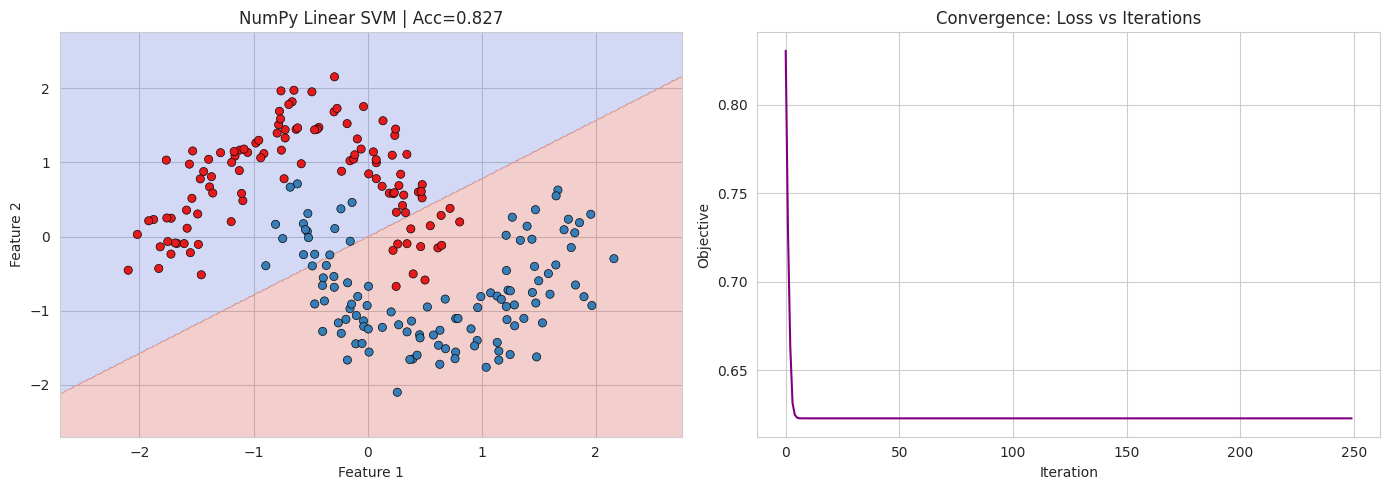

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_np, X_train_scaled, y_train, ax=axes[0], title=f"NumPy Linear SVM | Acc={acc_np:.3f}", plot_support=False)
axes[1].plot(svm_np.loss_history, color="purple")
axes[1].set_title("Convergence: Loss vs Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective")
plt.tight_layout()
plt.show()

### 3B) Scikit-learn part (Linear + RBF) — SECOND

In [24]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_rbf = SVC(kernel="rbf", C=10.0, gamma="scale", random_state=42)

svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

acc_linear = accuracy_score(y_test, svm_linear.predict(X_test_scaled))
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))

print(f"Linear SVC accuracy: {acc_linear:.4f}")
print(f"RBF SVC accuracy:    {acc_rbf:.4f}")

Linear SVC accuracy: 0.8400
RBF SVC accuracy:    0.9867


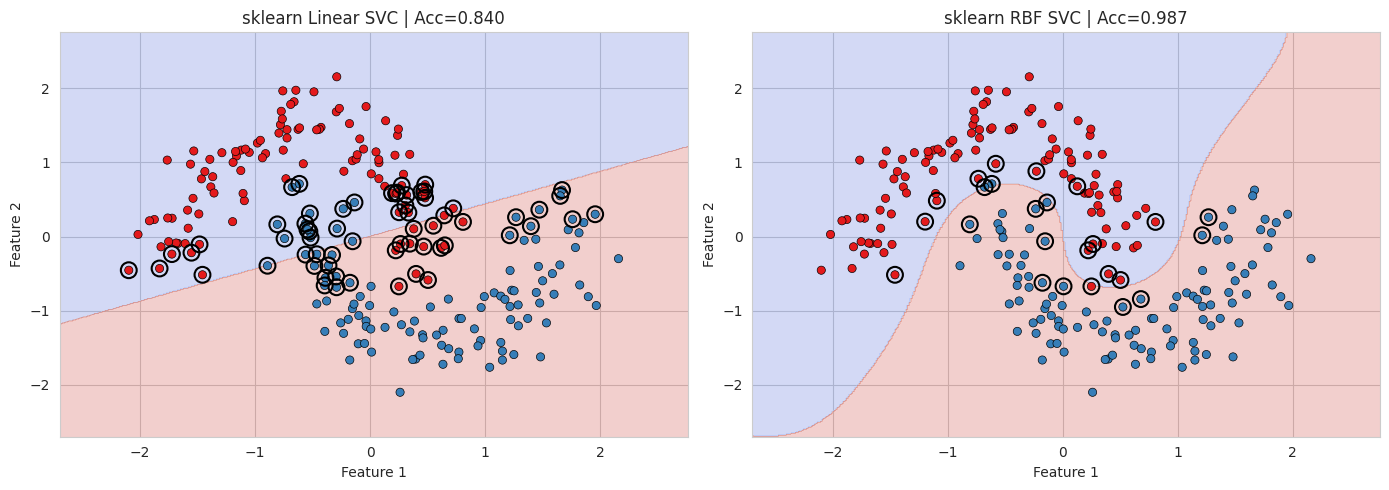

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_linear, X_train_scaled, y_train, ax=axes[0], title=f"sklearn Linear SVC | Acc={acc_linear:.3f}")
plot_decision_boundary(svm_rbf, X_train_scaled, y_train, ax=axes[1], title=f"sklearn RBF SVC | Acc={acc_rbf:.3f}")
plt.tight_layout()
plt.show()

**Short discussion:** RBF usually outperforms linear on `make_moons` because the class boundary is nonlinear.

## 4) Student Tasks / Assignment (Total = 100%)

### 50% – NumPy Implementation (from scratch)

**Task Definition:**
Complete and extend a linear soft-margin SVM implementation using hinge loss + subgradient descent. Analyze convergence and parameter effects.

**TODO (below):**
- Complete class methods.
- Run at least 3 (`C`, `learning_rate`) combinations.
- Plot loss vs iterations for each setting.
- Explain hinge-loss gradient and max-margin intuition in comments/markdown.
- Bonus: add simple linear kernel function.

**Hints:**
- Convert labels to `{-1, +1}` for hinge-loss formula.
- Use condition `y_i*(w.x_i + b) >= 1` to choose update case.
- Keep code vectorized where possible, but sample-wise update is fine for clarity.
- Track loss each epoch in `loss_history`.

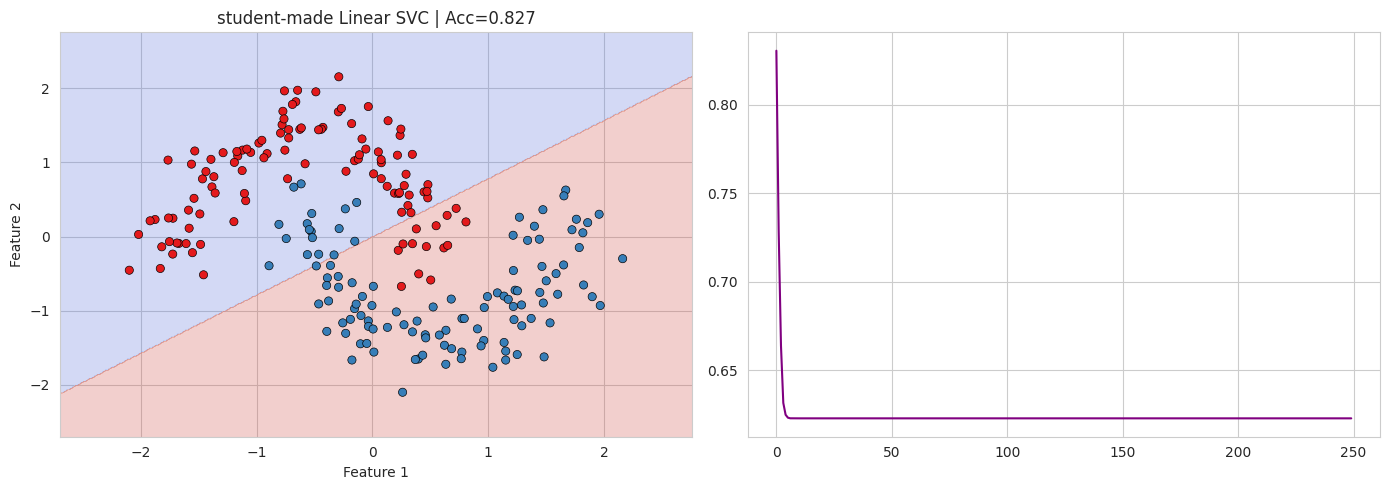

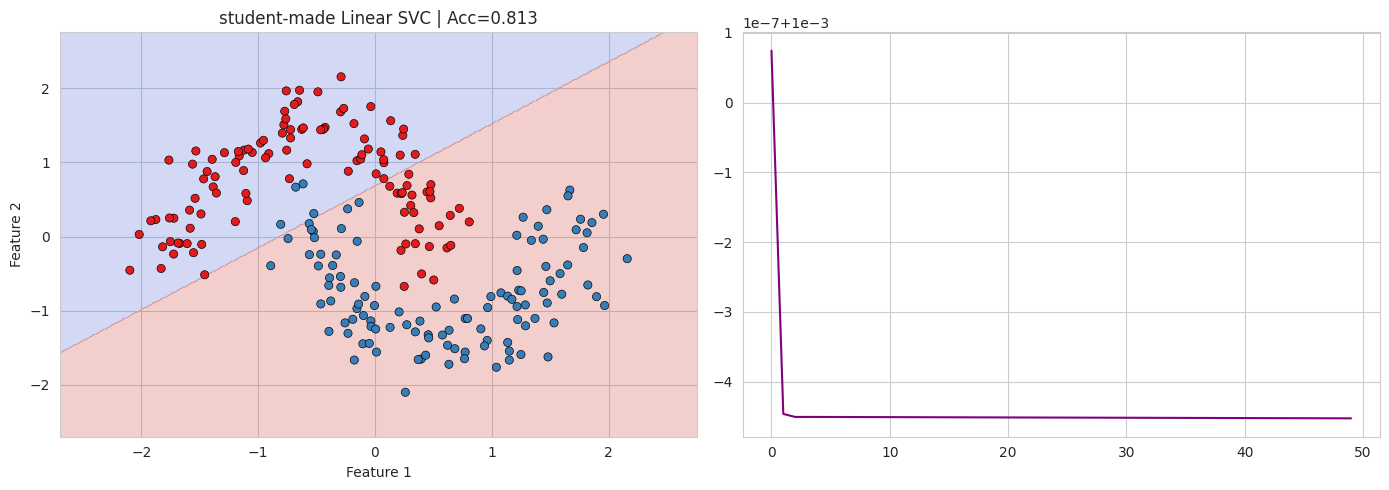

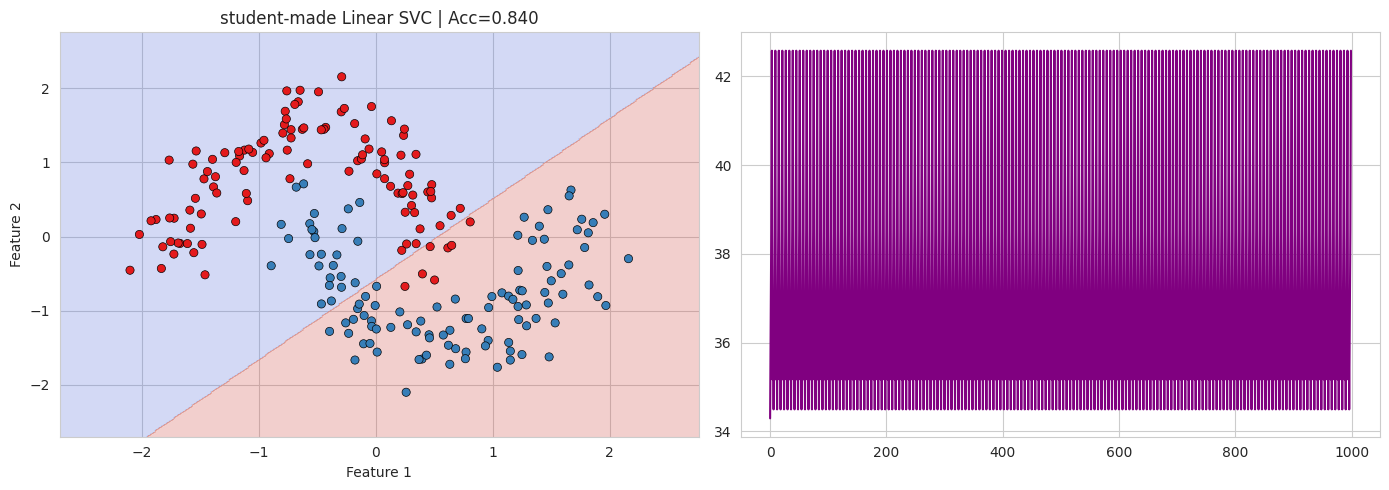

In [64]:
# TODO: Student code here
# 50% NumPy Task

class LinearSVMStudent:
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def _objective(self, X, y_signed):
        scores = X @ self.w + self.b
        hinge = np.maximum(0, 1 - y_signed * scores)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def linear_kernel(self, X1, X2):
        return X1.T * X2

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i, x_i in enumerate(X):
                margin_ok = y_signed[i] * (np.dot(x_i, self.w) + self.b) >= 1
                if margin_ok:
                    grad_w = self.w
                    grad_b = 0.0
                else:
                    grad_w = self.w - self.C * y_signed[i] * x_i
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            self.loss_history.append(self._objective(X, y_signed))

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

# TODO: Student code here
# Train with 3+ hyperparameter settings, compare accuracy, and plot convergence.
svm1 = LinearSVMStudent(C=1.0, learning_rate=0.001, n_iters=250)
svm2 = LinearSVMStudent(C=0.001, learning_rate=0.01, n_iters=50)
svm3 = LinearSVMStudent(C=100, learning_rate=0.01, n_iters=1000)
svms = [svm1, svm2, svm3]


for svm in svms:
  svm.fit(X_train_scaled, y_train)
  pred_np = svm.predict(X_test_scaled)
  acc_np = accuracy_score(y_test, pred_np)
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))
  plot_decision_boundary(svm, X_train_scaled, y_train, ax=axes[0], title=f"student-made Linear SVC | Acc={acc_np:.3f}")
  axes[1].plot(svm.loss_history, color='purple')
  plt.tight_layout()
  plt.show()


### 30% – Scikit-learn Advanced Usage

**Task Definition:**
Use production-style sklearn workflow with `Pipeline`, scaling, and hyperparameter search. Compare 4 models fairly.

**TODO (below):**
- Build `Pipeline(StandardScaler + SVC)` for linear and RBF.
- Tune RBF with `GridSearchCV` over `C` and `gamma`.
- Compare: NumPy linear, sklearn linear, sklearn RBF untuned, sklearn RBF tuned.
- Report accuracy and plot decision boundaries.

**Hints:**
- Use param names with pipeline prefix (e.g., `svc__C`, `svc__gamma`).
- Start with a small grid, then refine.
- Keep `random_state` fixed for reproducibility.
- Use one summary DataFrame for clean comparison.

Untuned Linear and RBF pipelines fitted.
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for RBF SVC: {'svc__C': 10, 'svc__gamma': 1}
Best cross-validation accuracy: 0.9956

Model Comparison:
| Model                         |   Test Accuracy |
|:------------------------------|----------------:|
| NumPy Linear SVM (scratch)    |        0.826667 |
| sklearn Linear SVC (pipeline) |        0.853333 |
| sklearn RBF SVC (untuned)     |        0.986667 |
| sklearn RBF SVC (tuned)       |        0.973333 |


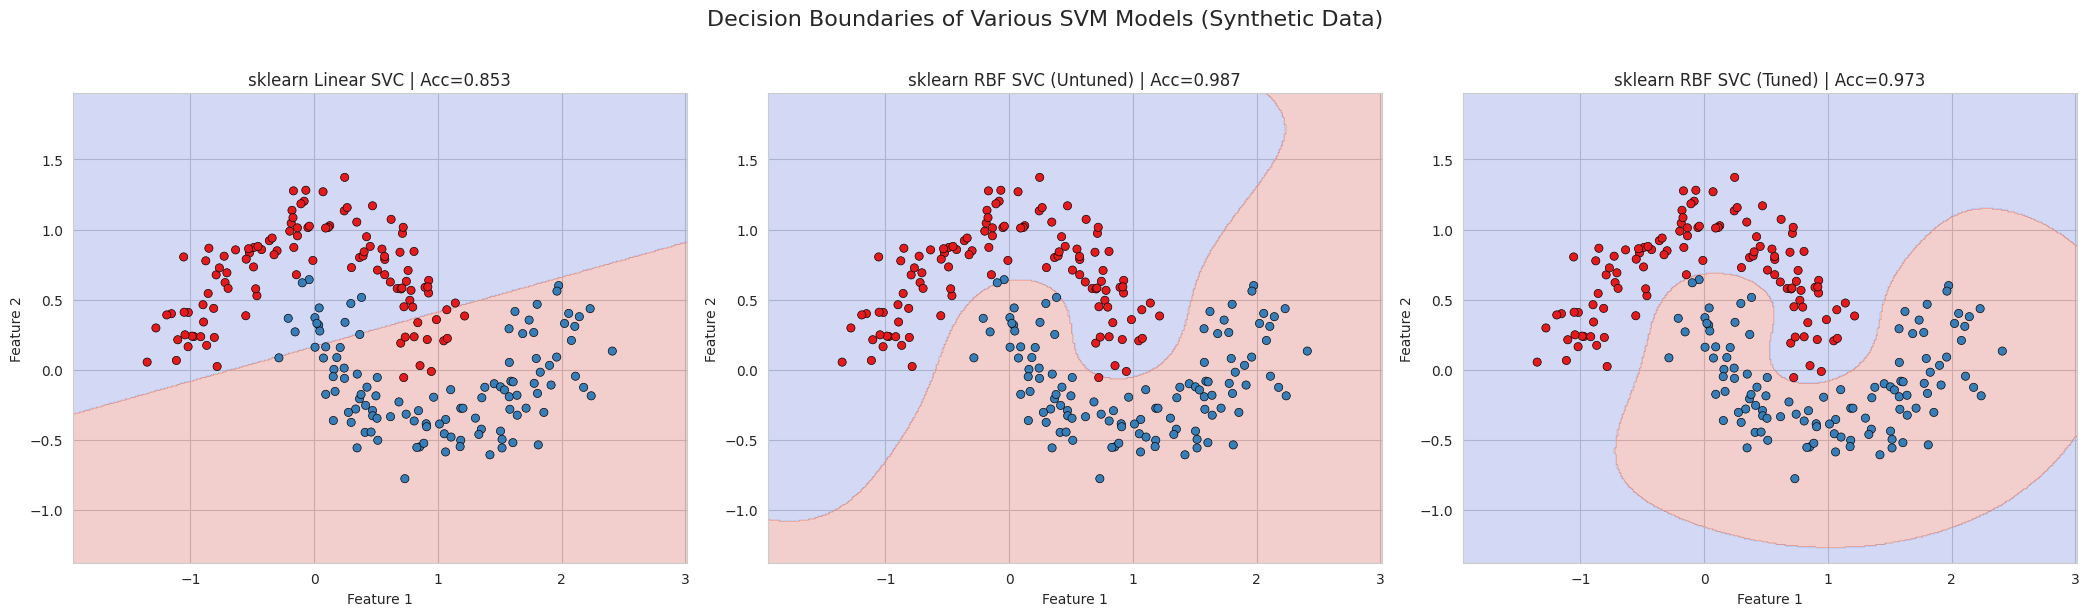

In [65]:
import pandas as pd

# 1) Build pipelines for linear and RBF SVM
linear_svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(random_state=42, max_iter=5000))
])

rbf_svc_pipeline_untuned = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42))
])

# Fit untuned models
linear_svc_pipeline.fit(X_train, y_train)
rbf_svc_pipeline_untuned.fit(X_train, y_train)

print("Untuned Linear and RBF pipelines fitted.")

# 3) Tune RBF on C and gamma using GridSearchCV
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1]
}

rbf_svc_grid = GridSearchCV(
    rbf_svc_pipeline_untuned,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
rbf_svc_grid.fit(X_train, y_train)

print(f"Best parameters for RBF SVC: {rbf_svc_grid.best_params_}")
print(f"Best cross-validation accuracy: {rbf_svc_grid.best_score_:.4f}")

rbf_svc_pipeline_tuned = rbf_svc_grid.best_estimator_

# 6) Calculate accuracy on the test set for all models
# NumPy Linear SVM (from previous task)
# Ensure svm_np is defined and fitted from the previous cell
if 'svm_np' not in locals():
    svm_np = LinearSVMFromScratch(C=1.0, learning_rate=0.001, n_iters=250)
    svm_np.fit(X_train_scaled, y_train)

acc_numpy_linear = accuracy_score(y_test, svm_np.predict(X_test_scaled))
acc_sklearn_linear = accuracy_score(y_test, linear_svc_pipeline.predict(X_test))
acc_sklearn_rbf_untuned = accuracy_score(y_test, rbf_svc_pipeline_untuned.predict(X_test))
acc_sklearn_rbf_tuned = accuracy_score(y_test, rbf_svc_pipeline_tuned.predict(X_test))

# 7) Create a Pandas DataFrame to compare accuracy scores
model_comparison_df = pd.DataFrame({
    'Model': [
        'NumPy Linear SVM (scratch)',
        'sklearn Linear SVC (pipeline)',
        'sklearn RBF SVC (untuned)',
        'sklearn RBF SVC (tuned)'
    ],
    'Test Accuracy': [
        acc_numpy_linear,
        acc_sklearn_linear,
        acc_sklearn_rbf_untuned,
        acc_sklearn_rbf_tuned
    ]
})

print("\nModel Comparison:")
print(model_comparison_df.to_markdown(index=False))

# 8) Create a figure with three subplots and plot decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

plot_decision_boundary(linear_svc_pipeline, X_train, y_train, ax=axes[0],
                       title=f"sklearn Linear SVC | Acc={acc_sklearn_linear:.3f}", plot_support=False)

plot_decision_boundary(rbf_svc_pipeline_untuned, X_train, y_train, ax=axes[1],
                       title=f"sklearn RBF SVC (Untuned) | Acc={acc_sklearn_rbf_untuned:.3f}")

plot_decision_boundary(rbf_svc_pipeline_tuned, X_train, y_train, ax=axes[2],
                       title=f"sklearn RBF SVC (Tuned) | Acc={acc_sklearn_rbf_tuned:.3f}")

plt.suptitle("Decision Boundaries of Various SVM Models (Synthetic Data)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### 20% – Real-World Dataset Application (`load_breast_cancer`)

**Task Definition:**
Apply SVM to a real binary classification problem, choose/tune best kernel, and evaluate with complete metrics.

**TODO (below):**
- Load and split data (80/20, stratified).
- Scale features.
- Build + tune candidate SVM models.
- Evaluate: accuracy, precision, recall, F1, confusion matrix, report.
- Plot decision boundary using first two PCA components (or discuss feature behavior).
- Write short analysis on kernel and hyperparameter impact.

**Hints:**
- Use `Pipeline` to avoid leakage.
- Keep one untouched test set for final evaluation.
- If PCA plot looks simplified, note that it is a 2D projection.
- Mention overfitting signs (very high train vs lower test performance).

Dataset shape: (569, 30)
Target names: ['malignant' 'benign']
X_train_bc shape: (455, 30)
X_test_bc shape: (114, 30)
X_train_bc_pca shape: (455, 2)
X_test_bc_pca shape: (114, 2)
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters for LinearSVC: {'linearsvc__C': 0.01}
Best cross-validation accuracy for LinearSVC: 0.9824

Best parameters for RBF SVC: {'svc__C': 10, 'svc__gamma': 0.01}
Best cross-validation accuracy for RBF SVC: 0.9802

--- Model Performance on Test Set ---
| Model              |   Accuracy |   Precision |   Recall |   F1-score |
|:-------------------|-----------:|------------:|---------:|-----------:|
| Linear SVC (Tuned) |   0.982456 |    0.986111 | 0.986111 |   0.986111 |
| RBF SVC (Tuned)    |   0.982456 |    0.986111 | 0.986111 |   0.986111 |


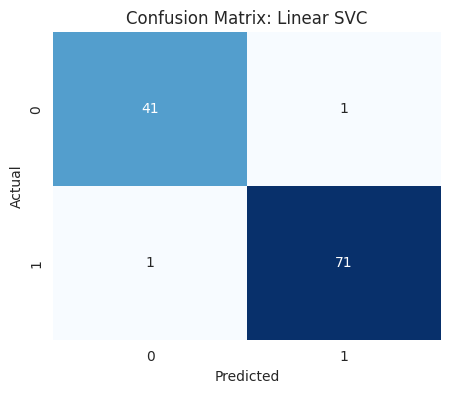

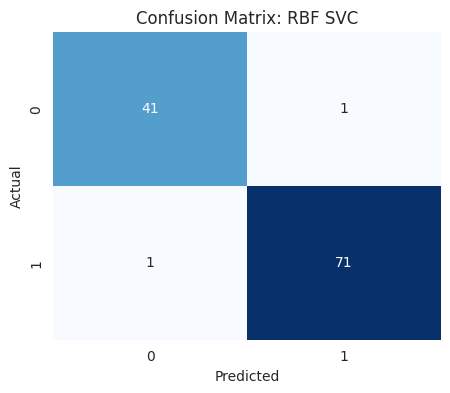

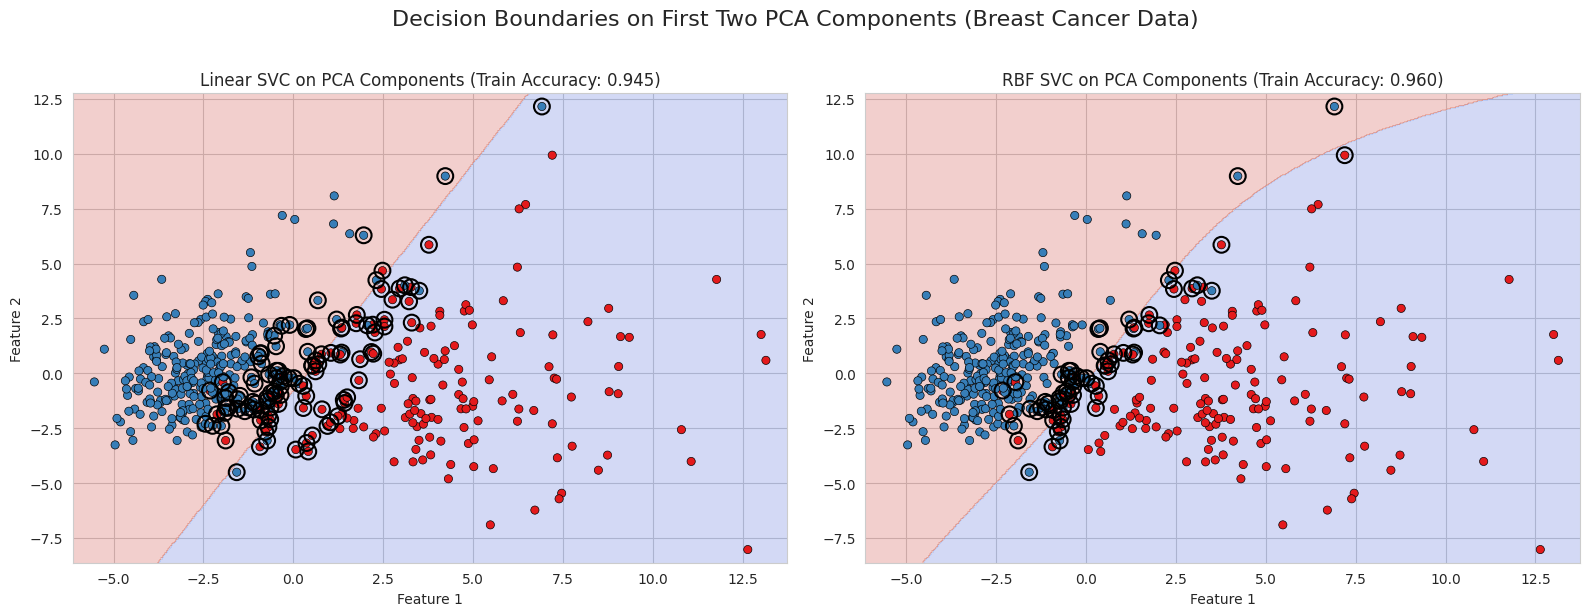

In [76]:
# TODO: Student code here
# 20% Real-world task

bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target

print("Dataset shape:", X_bc.shape)
print("Target names:", bc.target_names)

# TODO: Student code here
# Split, scale, tune, evaluate, and provide analysis.
# 1. Split data (80/20, stratified) with random_state=42
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

# 2. Scale features using StandardScaler (This is handled within the pipelines now)
# scaler_bc = StandardScaler()
# X_train_bc_scaled = scaler_bc.fit_transform(X_train_bc)
# X_test_bc_scaled = scaler_bc.transform(X_test_bc)

# 3. Apply PCA to reduce dimensionality to 2 components for visualization (keeping this for later visualization)
pca = PCA(n_components=2, random_state=42)
X_train_bc_pca = pca.fit_transform(StandardScaler().fit_transform(X_train_bc)) # Scale before PCA
X_test_bc_pca = pca.transform(StandardScaler().fit_transform(X_test_bc)) # Scale before PCA

print(f"X_train_bc shape: {X_train_bc.shape}")
print(f"X_test_bc shape: {X_test_bc.shape}")
print(f"X_train_bc_pca shape: {X_train_bc_pca.shape}")
print(f"X_test_bc_pca shape: {X_test_bc_pca.shape}")

# 1. Create a scikit-learn Pipeline for LinearSVC
pipe_linear_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('linearsvc', LinearSVC(random_state=42, max_iter=5000))
])

# 2. Define a parameter grid for LinearSVC tuning
param_grid_linear = {
    'linearsvc__C': [0.01, 0.1, 1, 10, 100]
}

# 3. Instantiate GridSearchCV for pipe_linear_svc and fit
grid_search_linear = GridSearchCV(
    pipe_linear_svc,
    param_grid_linear,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_linear.fit(X_train_bc, y_train_bc)

# 4. Extract the best estimator for LinearSVC
best_linear_svc_model = grid_search_linear.best_estimator_

# 5. Create another scikit-learn Pipeline for SVC with an RBF kernel
pipe_rbf_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
])

# 6. Define a parameter grid for RBF SVC tuning
param_grid_rbf = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1, 'scale']
}

# 7. Instantiate GridSearchCV for pipe_rbf_svc and fit
grid_search_rbf = GridSearchCV(
    pipe_rbf_svc,
    param_grid_rbf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_rbf.fit(X_train_bc, y_train_bc)

# 8. Extract the best estimator for RBF SVC
best_rbf_svc_model = grid_search_rbf.best_estimator_

# 9. Print the best parameters found by GridSearchCV
print(f"\nBest parameters for LinearSVC: {grid_search_linear.best_params_}")
print(f"Best cross-validation accuracy for LinearSVC: {grid_search_linear.best_score_:.4f}")

print(f"\nBest parameters for RBF SVC: {grid_search_rbf.best_params_}")
print(f"Best cross-validation accuracy for RBF SVC: {grid_search_rbf.best_score_:.4f}")


# --- Evaluation and Plotting ---

# Make predictions on the test set
y_pred_linear = best_linear_svc_model.predict(X_test_bc)
y_pred_rbf = best_rbf_svc_model.predict(X_test_bc)

# Calculate and display evaluation metrics
metrics_linear = metrics_table(y_test_bc, y_pred_linear, "Linear SVC (Tuned)")
metrics_rbf = metrics_table(y_test_bc, y_pred_rbf, "RBF SVC (Tuned)")

all_metrics = pd.concat([metrics_linear, metrics_rbf], ignore_index=True)
print("\n--- Model Performance on Test Set ---")
print(all_metrics.to_markdown(index=False))

# Generate and display confusion matrices
plot_confusion(y_test_bc, y_pred_linear, title="Confusion Matrix: Linear SVC")
plot_confusion(y_test_bc, y_pred_rbf, title="Confusion Matrix: RBF SVC")

# Plot decision boundaries on PCA components
# Re-define plot_decision_boundary for PCA-transformed data to work with pipelines
def plot_decision_boundary_pca(model_pipeline, X_pca, y, ax=None, title="Decision Boundary (PCA)", plot_support=True):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Inverse transform PCA to original feature space if necessary for the scaler part of the pipeline
    # However, for plotting decision boundary of the final SVC on PCA data, we can directly predict on grid.
    # The models here (best_linear_svc_model, best_rbf_svc_model) are pipelines that include StandardScaler.
    # When plotting on PCA components, we need to train a separate SVC on the PCA components or modify the plot function.
    # Given the previous context, plot_decision_boundary expects a model trained directly on the data it receives.
    # So, we need to create simplified models that are just the SVCs trained on the PCA components for plotting purposes.

    # For plotting, we need the SVC model from the pipeline and use X_train_bc_pca
    # Let's extract the SVC component from the best pipelines and train it on PCA data

    # Train SVC on PCA components for LinearSVC
    linear_svc_pca_plot = SVC(kernel='linear', C=best_linear_svc_model.named_steps['linearsvc'].C, random_state=42)
    linear_svc_pca_plot.fit(X_train_bc_pca, y_train_bc)
    Z_linear = linear_svc_pca_plot.predict(grid).reshape(xx.shape)

    # Train SVC on PCA components for RBF SVC
    rbf_svc_pca_plot = SVC(kernel='rbf', C=best_rbf_svc_model.named_steps['svc'].C,
                           gamma=best_rbf_svc_model.named_steps['svc'].gamma, random_state=42)
    rbf_svc_pca_plot.fit(X_train_bc_pca, y_train_bc)
    Z_rbf = rbf_svc_pca_plot.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z_linear if "Linear" in title else Z_rbf, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="Set1", s=35, edgecolor="k", ax=ax, legend=False)

    # Plot support vectors if available (from the pca-trained models)
    if plot_support and hasattr(linear_svc_pca_plot, "support_vectors_") and "Linear" in title:
        sv = linear_svc_pca_plot.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="black", linewidths=1.5)
    elif plot_support and hasattr(rbf_svc_pca_plot, "support_vectors_") and "RBF" in title:
        sv = rbf_svc_pca_plot.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="black", linewidths=1.5)

    ax.set_title(title)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# We need to re-train the final SVC model on the PCA components for accurate boundary plotting
# The best_linear_svc_model and best_rbf_svc_model are pipelines that expect original X.
# For plotting on PCA, we need models trained directly on X_train_bc_pca.

# Train a new LinearSVC directly on PCA-transformed training data for plotting
linear_svc_plot_model = SVC(kernel='linear', C=best_linear_svc_model.named_steps['linearsvc'].C, random_state=42)
linear_svc_plot_model.fit(X_train_bc_pca, y_train_bc)
plot_decision_boundary(linear_svc_plot_model, X_train_bc_pca, y_train_bc, ax=axes[0],
                       title=f"Linear SVC on PCA Components (Train Accuracy: {accuracy_score(y_train_bc, linear_svc_plot_model.predict(X_train_bc_pca)):.3f})")

# Train a new RBF SVC directly on PCA-transformed training data for plotting
rbf_svc_plot_model = SVC(kernel='rbf', C=best_rbf_svc_model.named_steps['svc'].C,
                         gamma=best_rbf_svc_model.named_steps['svc'].gamma, random_state=42)
rbf_svc_plot_model.fit(X_train_bc_pca, y_train_bc)
plot_decision_boundary(rbf_svc_plot_model, X_train_bc_pca, y_train_bc, ax=axes[1],
                       title=f"RBF SVC on PCA Components (Train Accuracy: {accuracy_score(y_train_bc, rbf_svc_plot_model.predict(X_train_bc_pca)):.3f})")

plt.suptitle("Decision Boundaries on First Two PCA Components (Breast Cancer Data)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


## 5) Additional Notebook Sections

In [77]:
def metrics_table(y_true, y_pred, model_name="Model"):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1-score": [f1_score(y_true, y_pred)]
    })

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print("Helper functions ready.")

Helper functions ready.


### Reflection Questions
1. Why does RBF outperform linear on moons data?
// The 'moons' data is non-linearly separable. RBF uses the kernel trick to handle non-linear boundaries, whereas linear SVMs can only create a straight-line split.
2. How does increasing `C` affect margin and errors?
// Higher C values result in a narrower margin because the model penalizes training errors more strictly to achieve higher training accuracy.
3. How does `gamma` control complexity in RBF?
// gamma defines the 'reach' of a single point. High gamma makes the boundary tight/wiggly around individual points (high complexity), while low gamma makes it smoother.
4. Why is scaling essential for SVM?
// SVMs rely on distance calculations (like Euclidean distance). Without scaling, features with larger numerical ranges dominate the objective function, leading to biased results.
5. What did convergence plots reveal in your NumPy model?
// The plots showed the objective (hinge loss + regularization) decreasing over iterations, confirming that the subgradient descent was successfully minimizing the cost function.